## MEDICAL INSURANCE COST PREDICTION USING MACHINE LEARNING

### Importing the dependencies

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

### Data Collection & Analysis


In [2]:
# loading the data from csv file to a Pandas Dataframe
insurance_dataset = pd.read_csv('insurance.csv')

In [3]:
# first 5 rows of the dataframe
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Understanding the data
insurance_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
# type of data
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
for col in insurance_dataset.columns:
    print(f"{col}: {insurance_dataset[col].unique()}")


age: [19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]
sex: ['female' 'male']
bmi: [27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31.68  22.88  37.335
 27.36  33.66  24.7   25.935 22.42  28.9   39.1   36.19  23.98  24.75
 28.5   28.1   32.01  27.4   34.01  29.59  35.53  39.805 26.885 38.285
 37.62  41.23  34.8   22.895 31.16  27.2   26.98  39.49  24.795 31.3
 38.28  19.95  19.3   31.6   25.46  30.115 29.92  27.5   28.4   30.875
 27.94  35.09  29.7   35.72  32.205 28.595 49.06  27.17  23.37  37.1
 23.75  28.975 31.35  33.915 28.785 28.3   37.4   17.765

In [7]:
# number of rows and columns
insurance_dataset.shape

(1338, 7)

Categorical Features :
- Sex
- Smoker
- Region

In [8]:
# Checking for missing values
insurance_dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
# Statistical view of the dataset
insurance_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


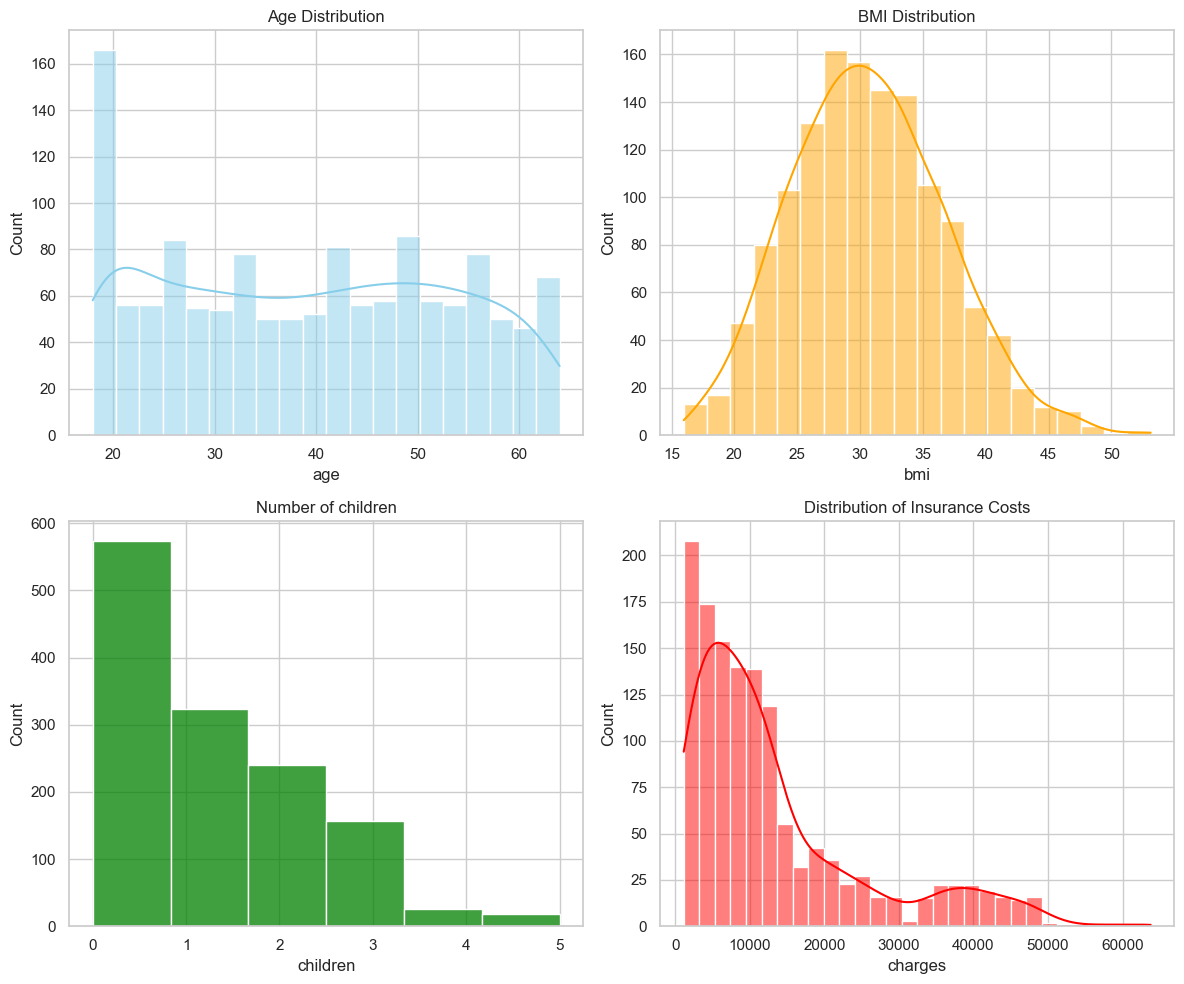

In [10]:
# Creating visualizations of the numeric variables to see patterns

sns.set(style="whitegrid")

# Create histograms for numerical variables
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

sns.histplot(insurance_dataset['age'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

sns.histplot(insurance_dataset['bmi'], bins=20, kde=True, ax=axes[1], color='orange')
axes[1].set_title('BMI Distribution')

sns.histplot(insurance_dataset['children'], bins=6, kde=False, ax=axes[2], color='green')
axes[2].set_title('Number of children')

sns.histplot(insurance_dataset['charges'], bins=30, kde=True, ax=axes[3], color='red')
axes[3].set_title('Distribution of Insurance Costs')


plt.tight_layout()
plt.show()

Initial Insights:
Age: Fairly even distribution, with peaks between 20 and 60 years old.

BMI (Body Mass Index): Most data is between 20 and 40, with some cases of severe obesity.

Children: Most have no children or between 1 and 2.

Insurance costs: Distribution highly skewed to the right - many pay little, a few pay a lot (outliers!).

Now we are going to analize how does the variable "charges" changes influenced by:
* Sex
* Smoker or not smoker
* Region
* Children

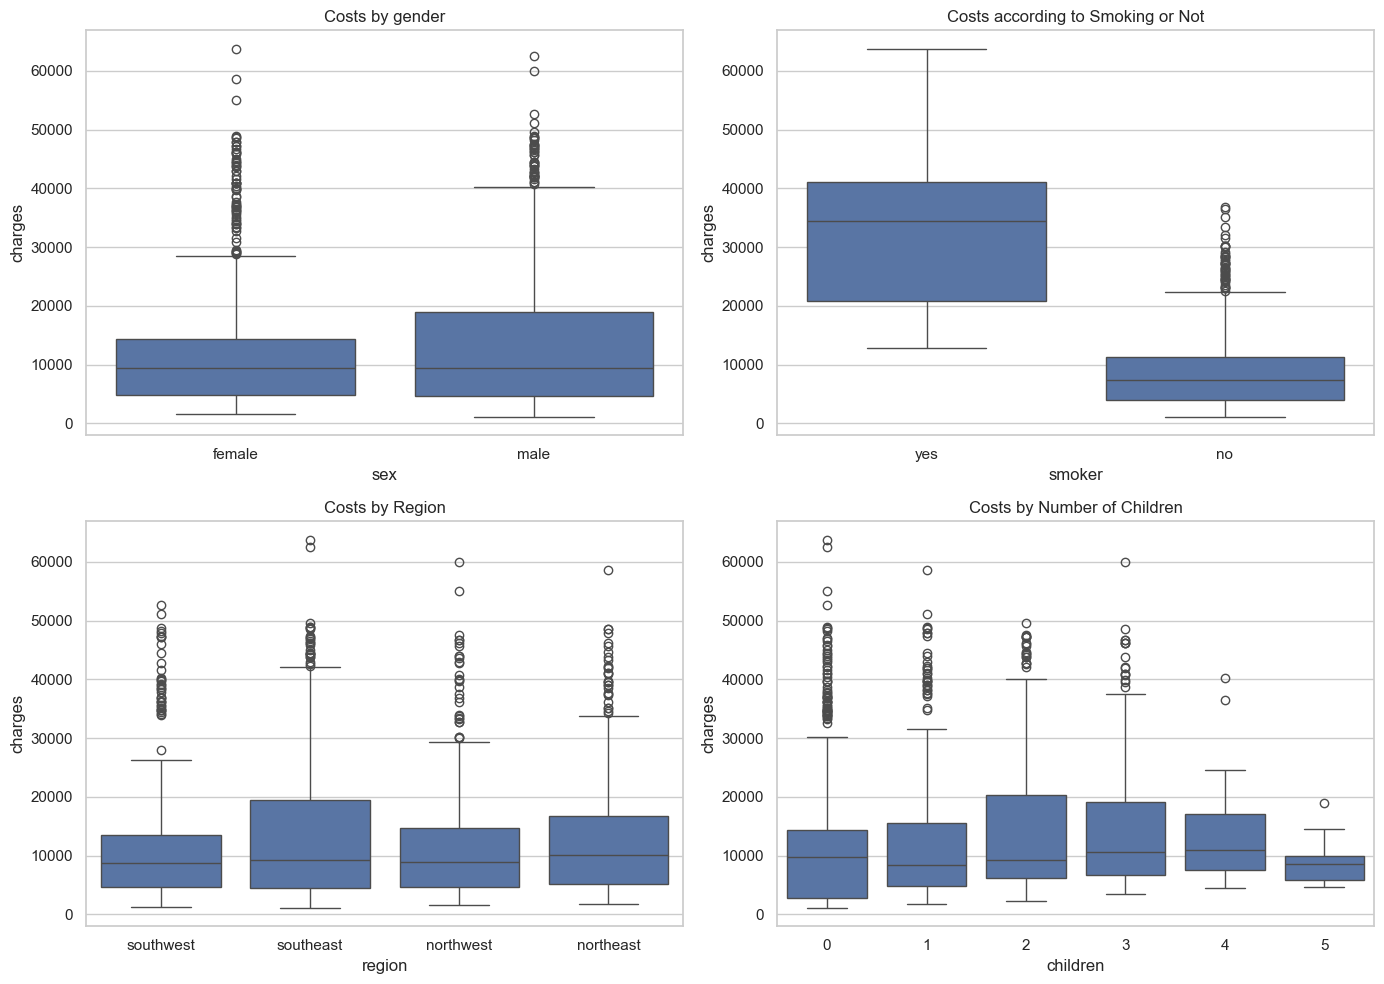

In [11]:
# Create boxplots to see how charges vary according to categorical variables.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

sns.boxplot(x='sex', y='charges', data= insurance_dataset, ax=axes[0])
axes[0].set_title('Costs by gender')

sns.boxplot(x='smoker', y='charges', data= insurance_dataset, ax=axes[1])
axes[1].set_title('Costs according to Smoking or Not')

sns.boxplot(x='region', y='charges', data= insurance_dataset, ax=axes[2])
axes[2].set_title('Costs by Region')

sns.boxplot(x='children', y='charges', data= insurance_dataset, ax=axes[3])
axes[3].set_title('Costs by Number of Children')

plt.tight_layout()
plt.show()

Boxplots Insights:
Smoking vs. Non-smoking: Brutal difference. Smokers have clearly higher spending. This variable is key.

Gender: Virtually no difference between men and women in medical spending.

Region: Very slight differences between regions. Probably not a relevant variable.

Children: No clear pattern. Having more children does not necessarily imply higher spending.

## Analize the correlation between variables

Let´s see the correlation between the variable charges and the others

We will use the correlation heatmap.

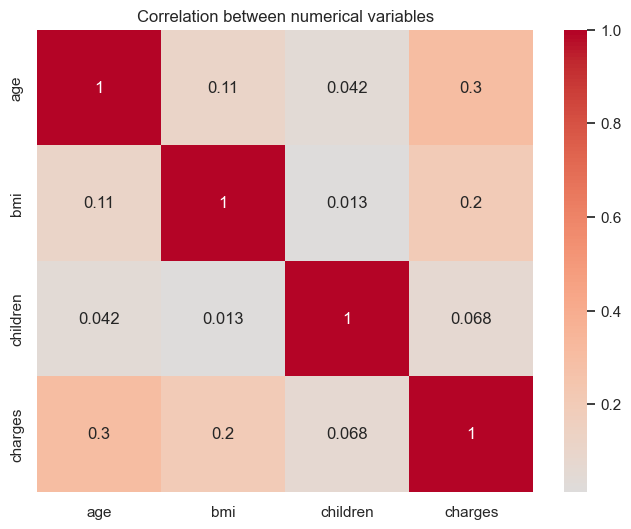

In [12]:
# numerical correlation heatmap
corr = insurance_dataset[['age', 'bmi', 'children', 'charges']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation between numerical variables')
plt.show()

Correlation map interpretation:
Age vs. Charges → High positive correlation (+0.3): The older, the more you pay.

BMI vs. Charges → Moderate correlation (+0.2): If combined with smoking, can be powerful.

Children barely correlates: explains almost none of the spending.

## Partial conclusion:
Medical costs soar among smokers, especially if they have a high BMI and are older. All other factors have little effect. We can use this info to create an adjusted cost prediction or to design prevention policies.

## Linear Regression Model 

In [13]:

# Separate features and target variable
X = insurance_dataset.drop('charges', axis=1)
y = insurance_dataset['charges']

# Categorical and numerical columns
cat_features = ['sex', 'smoker', 'region']
num_features = ['age', 'bmi', 'children']  # Note: replaced 'Kinder' with 'children'

# Preprocessing pipeline and model
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), cat_features)
], remainder='passthrough')

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, r2



(np.float64(4181.194473753659), 0.7835929767120722)

Trained Linear Regression Model
Model performance:

📉 MAE (mean absolute error): €4,181
→ On average, the model is wrong by about €4,181 per prediction.

📊 R² (coefficient of determination): 0.78
→ The model explains 78% of the variability in health insurance expenditure.

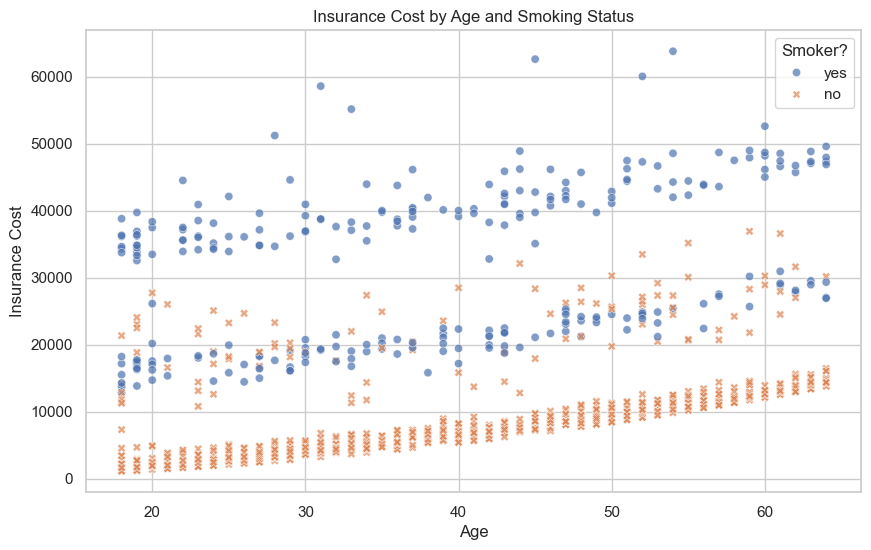

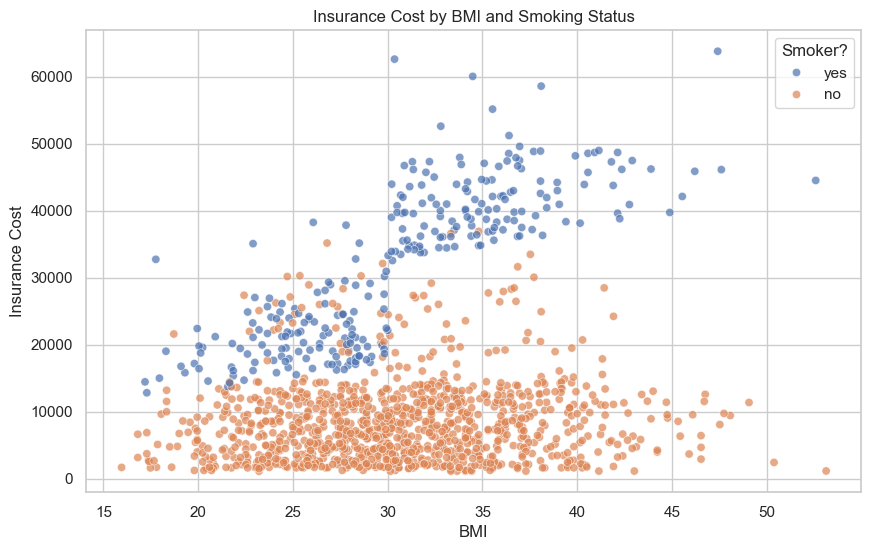

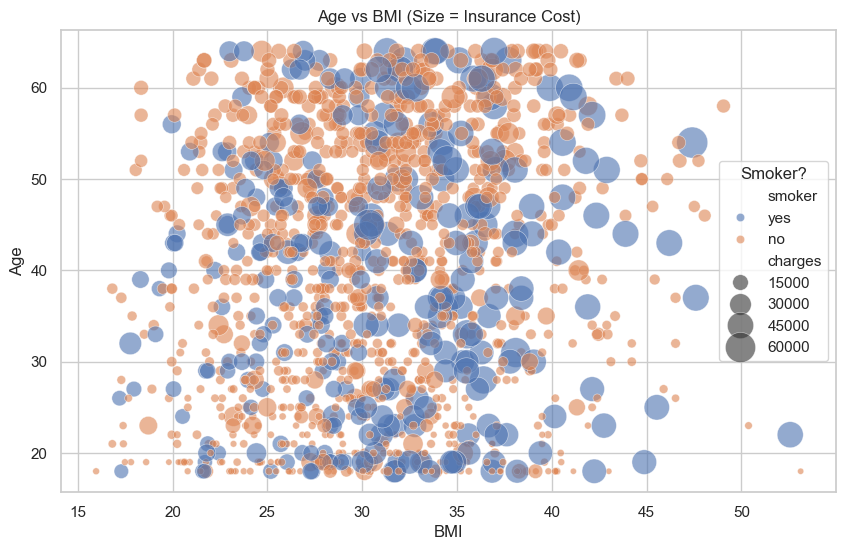

In [15]:
# Advanced Visualization 1: Charges by Age and Smoking Status
plt.figure(figsize=(10, 6))
sns.scatterplot(data=insurance_dataset, x='age', y='charges', hue='smoker', style='smoker', alpha=0.7)
plt.title('Insurance Cost by Age and Smoking Status')
plt.xlabel('Age')
plt.ylabel('Insurance Cost')
plt.legend(title='Smoker?')
plt.show()

# Advanced Visualization 2: BMI vs Charges colored by Smoking Status
plt.figure(figsize=(10, 6))
sns.scatterplot(data=insurance_dataset, x='bmi', y='charges', hue='smoker', alpha=0.7)
plt.title('Insurance Cost by BMI and Smoking Status')
plt.xlabel('BMI')
plt.ylabel('Insurance Cost')
plt.legend(title='Smoker?')
plt.show()

# Advanced Visualization 3: BMI + Age → Cost (Proportional Size)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=insurance_dataset, x='bmi', y='age', size='charges', hue='smoker', alpha=0.6, sizes=(20, 500))
plt.title('Age vs BMI (Size = Insurance Cost)')
plt.xlabel('BMI')
plt.ylabel('Age')
plt.legend(title='Smoker?')
plt.show()


## Advanced interpretation of visualizations


### Age vs. Charges:

Smokers (color) have very high charges starting at age 30-35.

There is a clear upward curve with age, more pronounced if you smoke.

### BMI vs. Charges:

If you don't smoke, even if you are overweight (high BMI), the expense does not go up much.

If you smoke and have a high BMI → costs skyrocket (upper right area).

### Age vs. BMI (size = expense):

Large circles (high costs) are concentrated in:

High ages

BMI > 30

And mostly smokers (color)

### Ultimate conclusion:
The most at-risk customer profile for an insurer is a smoker with mild to moderate obesity (BMI &gt; 30) and age between 45 and 60.
Intervening in health habits and smoking cessation can reduce medical expenses by up to €23,000 per person.

